In [2]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from matplotlib.colors import to_rgba
from globalVars import *
from load_data_pickles import *
from analysis import mean_and_interquartile
from plotting_variables import TINY_SIZE, SMALL_SIZE

In [3]:
# fit empiriccal data with a 1st or 2nd order system model with delay

tau = .321 # (fixed) delay in seconds

def model_1st_response_with_delay(params, omegas_rad, dt=1/60):
    """Evaluate 2nd order + delay at omegas. Uses same structure as second()."""
    a0, b0, b1 = params
    n_freq = len(omegas_rad)
    H = np.zeros(n_freq, dtype=complex)
    for i, omega in enumerate(omegas_rad):
        zi = np.exp(1j * omega * dt)
        H[i] =  np.exp(-1j * omega * tau)*(b0*zi + b1) / (zi + a0)
    return H

# Model: H(z) = (b0*z^2 + b1*z + b2)*np.exp(-1j * omega * tau) / (z^2 + a0*z + a1), z = exp(j*omega*dt)
def model_2nd_response_with_delay(params, omegas_rad, dt=1/60):
    """Evaluate 2nd order + delay at omegas. Uses same structure as second()."""
    a0, a1, b0, b1, b2 = params
    n_freq = len(omegas_rad)
    H = np.zeros(n_freq, dtype=complex)
    for i, omega in enumerate(omegas_rad):
        zi = np.exp(1j * omega * dt)
        H[i] =  np.exp(-1j * omega * tau)*(b0*zi**2 + b1*zi + b2) / (zi**2 + a0*zi + a1)
    return H

def fit_1st_order(data, omegas_rad, inits = [0.1,0.1,0.1], bounds = [(-2.5, 2.5), (-5, 5), (-10, 10)], dt=1/60):
    """Fit MH freq response with a 1st order discrete-time model. Returns [a0,b0,b1]."""
    data = np.asarray(data)
    def cost(params):
        return np.sum(np.abs(data - model_1st_response_with_delay(params, omegas_rad))**2)
    res = minimize(cost, inits, method='L-BFGS-B', bounds=bounds) 
    return res.x, res.fun

def fit_2nd_order(data, omegas_rad, inits = [0.1,0.1,0.1,0.1,0.1], bounds=[(-2.5, 2.5), (-1, 1), (-5, 5), (-10, 10), (-5, 5)], dt=1/60):
    """Fit MH freq response with a 2nd order discrete-time model. Returns [a0,a1,b0,b1,b2]."""
    data = np.asarray(data)
    def cost(params):
        return np.sum(np.abs(data - model_2nd_response_with_delay(params, omegas_rad))**2)
    res = minimize(cost, inits, method='L-BFGS-B', bounds=bounds) 
    return res.x, res.fun

# sweeping through multiple initial conditions and bounds to find the best fit for 1st and 2nd order models

from itertools import product
def fit_1st_order_sweep(data, omegas_rad, inits_list, bounds_list, dt=1/60, return_all=False):
    """Sweep over (init, bounds) pairs and return the 1st-order fit with the lowest cost.
    inits_list: list of initial guess arrays, each of length 3 [a0, b0, b1]
    bounds_list: list of bounds, each a list of 3 (lo, hi) tuples
    Tries all combinations. Returns (best_params, best_cost). If return_all=True, also returns
    list of (params, cost, init_idx, bounds_idx) for every run."""
    best_params, best_cost = None, np.inf
    all_results = []
    for (ii, inits), (ib, bounds) in product(enumerate(inits_list), enumerate(bounds_list)):
        params, cost = fit_1st_order(data, omegas_rad, inits=inits, bounds=bounds, dt=dt)
        all_results.append((params, cost, ii, ib))
        if cost < best_cost:
            best_cost = cost
            best_params = params
    if return_all:
        return best_params, best_cost, all_results
    return best_params, best_cost

def fit_2nd_order_sweep(data, omegas_rad, inits_list, bounds_list, dt=1/60, return_all=False):
    """Sweep over (init, bounds) pairs and return the 2nd-order fit with the lowest cost.
    inits_list: list of initial guess arrays, each of length 5 [a0, a1, b0, b1, b2]
    bounds_list: list of bounds, each a list of 5 (lo, hi) tuples
    Tries all combinations. Returns (best_params, best_cost). If return_all=True, also returns
    list of (params, cost, init_idx, bounds_idx) for every run."""
    best_params, best_cost = None, np.inf
    all_results = []
    for (ii, inits), (ib, bounds) in product(enumerate(inits_list), enumerate(bounds_list)):
        params, cost = fit_2nd_order(data, omegas_rad, inits=inits, bounds=bounds, dt=dt)
        all_results.append((params, cost, ii, ib))
        if cost < best_cost:
            best_cost = cost
            best_params = params
    if return_all:
        return best_params, best_cost, all_results
    return best_params, best_cost

# 2nd-order human model

In [ ]:
# make a range to sweep over for each parameter, then try all combinations
inits_list = [] 
# bounds_list = []
param_ranges = [
    np.linspace(-2.5, 2.5, 5), # a0
    np.linspace(-1, 1, 5),     # a1
    np.linspace(-5, 5, 5),     # b0
    np.linspace(-10, 10, 5),   # b1
    np.linspace(-5, 5, 5)      # b2
]
# Generate all combinations of inits and bounds
for a0_init in param_ranges[0]:
    for a1_init in param_ranges[1]:
        for b0_init in param_ranges[2]:
            for b1_init in param_ranges[3]:
                for b2_init in param_ranges[4]:
                    inits_list.append([a0_init, a1_init, b0_init, b1_init, b2_init])
# Use sweep to get the best 1st-order fit over multiple inits and bounds
inits_list = [[0.1, 0.1, 0.1, 0.1, 0.1], 
            [0.2, 0.2, 0.2, 0.2, 0.2],
            [0.5, 0.5, 0.5, 0.5, 0.5], 
            [-0.1, -0.1, -0.1, -0.1, -0.1],
            [0,0,0,0,0],
            [1,1,1,1,1]
]
bounds_list = [
    [(-10, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10)],
    [(-2.5, 2.5), (-1, 1), (-5, 5), (-10, 10), (-5, 5)],
    [(-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1)]
]

In [5]:
# fit a model for each trials
H_2nd_params = np.zeros((subject_num, len(condition_orders), trial_num, 5)) # 5 parameters for 2nd order model
H_2nd_fits = np.zeros((subject_num, len(condition_orders), trial_num, len(IX)),dtype = complex) # fitted H for each trial, at stimulated frequencies

for sub in range(subject_num):
    for cond, condition in enumerate(condition_orders):
        for trial in range(trial_num):
            H_empirical = Hs[sub,cond,trial,IX] # per trial
            best_params, best_cost, all_results = fit_2nd_order_sweep(H_empirical, omegas, inits_list, bounds_list, return_all=True)
            H_fit = model_2nd_response_with_delay(best_params, omegas)
            H_2nd_params[sub,cond,trial] = best_params
            H_2nd_fits[sub,cond,trial] = H_fit
print(H_2nd_params.shape)
print(H_2nd_fits.shape)

# fit a model for each trials baseline
H_2nd_params_base = np.zeros((subject_num, trial_num_base, 5)) # 5 parameters for 2nd order model
H_2nd_fits_base = np.zeros((subject_num, trial_num_base, len(IX)),dtype = complex) # fitted H for each trial, at stimulated frequencies

for sub in range(subject_num):
    for trial in range(trial_num_base):
        H_empirical = Hs_base[sub,trial,IX] # per trial
        best_params, best_cost, all_results = fit_2nd_order_sweep(H_empirical, omegas, inits_list, bounds_list, return_all=True)
        H_fit = model_2nd_response_with_delay(best_params, omegas)
        H_2nd_params_base[sub,trial] = best_params
        H_2nd_fits_base[sub,trial] = H_fit
print(H_2nd_params_base.shape)
print(H_2nd_fits_base.shape)

(11, 3, 21, 5)
(11, 3, 21, 8)
(11, 12, 5)
(11, 12, 8)


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_96954/1427398595.py:85: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',color = 'red',label = 'I*',linestyle='--')
/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_96954/1427398595.py:94: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',color = 'red',label = 'I*',linestyle='--')


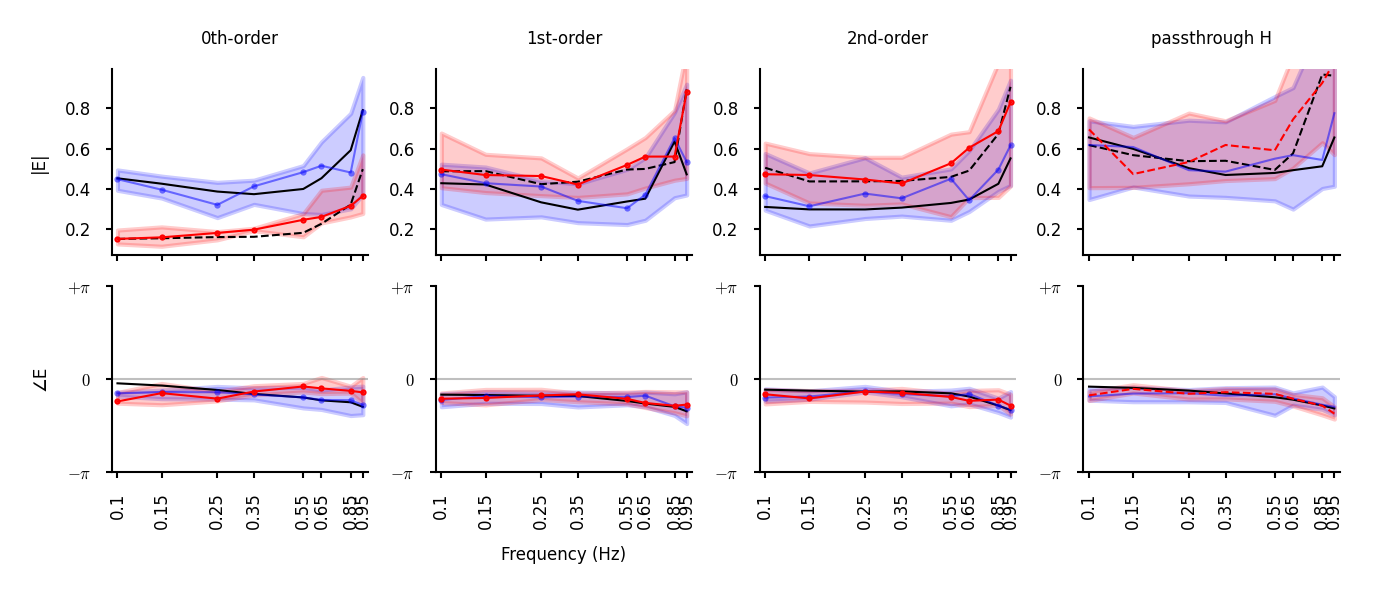

In [5]:
# plot the fitted models, overlaying with the empirical

# Bode plot of this PD controller for each condition
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.095, 1.0)
ylimphase = (-np.pi,np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
trial_num = Hs.shape[2]
# update_trials = [0,4,9]
update_trials = [0,3,17]
update_trials = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
trial = 17 # last adaptive trial
# avg baseline G
# Gs_base_mean = np.mean(Gs_base[sub],axis=0)
fig,axs = plt.subplots(2,4,sharex=True,figsize=(4.5,1.9),dpi=300)

for cond, condition in enumerate(condition_orders):
    
    ax = axs[0,cond]
    # mean across 3 trials 
    I_last_3_trials = np.mean(H_2nd_fits[:,cond,15:18,:],axis = 1) # last 3 adaptive trials 
    I_first_3_trials = np.mean(H_2nd_fits[:,cond,:3,:],axis = 1) # first 3 fixed trials

    # mean across subjects
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(I_last_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',color = 'black')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(I_first_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'--',color = 'black')

    ax = axs[1,cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(I_last_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',color = 'black')


    # empirical data
    H_last_3_trials = np.mean(Hs[:,cond,15:18,:][:,:,IX],axis = 1) # last 3 adaptive trials 
    H_first_3_trials = np.mean(Hs[:,cond,:3,:][:,:,IX],axis = 1) # first 3 fixed trials

    ax = axs[0,cond]
    # mean across subjects
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_last_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'blue',alpha=0.5)
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_first_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',label = 'I*')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red')
    ax.set_title(str(condition)+'-order')

    ax = axs[1,cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_last_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'blue',alpha=0.5)
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_first_3_trials), axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',label = 'I*')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red')


# fitted
ax = axs[0,-1]
# mean across 3 trials 
I_last_3_trials = np.mean(H_2nd_fits_base[:,-3:,:],axis = 1) # last 3 adaptive trials 
I_first_3_trials = np.mean(H_2nd_fits_base[:,:3,:],axis = 1) # first 3 fixed trials

# mean across subjects
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(I_last_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'black')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(I_first_3_trials), axis = 0)
ax.plot(freqs,quantile50,'--',color = 'black')

ax = axs[1,-1]
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(I_last_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'black')

# empirical
ax = axs[0,-1]
# mean across 3 trials 
H_base_last_3_trials = np.mean(Hs_base[:,-3:,:][:,:,IX],axis = 1) # last 3 fixed trials 
H_base_first_3_trials = np.mean(Hs_base[:,:3,:][:,:,IX],axis = 1) # first 3 fixed trials
# mean across subjects
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_base_last_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'blue',alpha=0.5)
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_base_first_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'red',label = 'I*',linestyle='--')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red')
ax.set_title('passthrough H')

ax = axs[1,-1]
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_base_last_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'blue',alpha=0.5)
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_base_first_3_trials), axis = 0)
ax.plot(freqs,quantile50,'-',color = 'red',label = 'I*',linestyle='--')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red')

for j in range(4):
    ax = axs[0,j]
    ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axs[1,j]
    # ax.grid('on',zorder=-1)
    ax.set_ylim(ylimphase)
    ax.set_yticks(yticksphase)
    ax.set_yticklabels(yticklabelsphase)
    ax.set_xticklabels(xticks,rotation=90) 
    ax.axhline(y = 0, color = 'grey', alpha = 0.5, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for j in range(1, 4):
    axs[0, j].sharey(axs[0, 0])

# axs[0,0].set_ylabel('Magnitude')
# axs[1,0].set_ylabel('Phase')
# axs[1,1].set_xlabel('Non-stim Frequency (Hz)')

axs[0,0].set_ylabel('|E|')
axs[1,0].set_ylabel('∠E')
axs[1,1].set_xlabel('Frequency (Hz)')

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

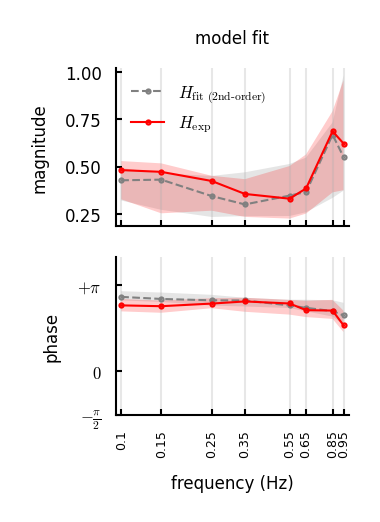

In [6]:


xlim = (0.095, 1.0)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
ylimphase = (-np.pi/2,np.pi+1)
yticksphase = [-np.pi/2,0.,np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$',r'$+\pi$']

fig,axs = plt.subplots(2,1,sharex=True,figsize=(1,1.5),dpi = 300)
cond = 1
ax = axs[0]
H_last_3_trials = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials  # invert H to match paper figure
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit (2nd-order)}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# overlay exp result
H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1,label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([]) 
ax.set_ylabel('magnitude')
ax.set_title('model fit')
ax.tick_params(axis='y')

ax = axs[1]
H_last_3_trials = np.mean(np.angle(-H_2nd_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# # overlay exp result
H_last_3_trials = np.mean(np.angle(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1, label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90, fontsize=TINY_SIZE-1) 
ax.set_ylabel('phase') 
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left',frameon = False,ncol = 1)
plt.show()

# 1st-order human model

In [8]:
inits_list = [[0.1, 0.1, 0.1], 
            [0.2, 0.2, 0.2], 
            [0.5, 0.5, 0.5], 
            [-0.1, -0.1, -0.1],
            [0,0,0],
            [1,1,1]]
bounds_list = [
    [(-2.5, 2.5), (-5, 5), (-10, 10)],
    [(-10, 10), (-10, 10), (-10, 10)],
    [(-2.5, 2.5), (-2.5, 2.5), (-2.5, 2.5)]
]

In [9]:
# fit a 1st-order model for each trial
H_1st_params = np.zeros((subject_num, len(condition_orders), trial_num, 3)) # 3 parameters for 1st order model
H_1st_fits = np.zeros((subject_num, len(condition_orders), trial_num, len(IX)), dtype=complex) # fitted H at stimulated frequencies

for sub in range(subject_num):
    for cond, condition in enumerate(condition_orders):
        for trial in range(trial_num):
            H_empirical = Hs[sub, cond, trial, IX] # per trial
            best_params, best_cost, all_results = fit_1st_order_sweep(H_empirical, omegas, inits_list, bounds_list, return_all=True)
            H_fit = model_1st_response_with_delay(best_params, omegas)
            H_1st_params[sub, cond, trial] = best_params
            H_1st_fits[sub, cond, trial] = H_fit
print(H_1st_params.shape)
print(H_1st_fits.shape)

# fit a 1st-order model for each baseline trial
H_1st_params_base = np.zeros((subject_num, trial_num_base, 3)) # 3 parameters for 1st order model
H_1st_fits_base = np.zeros((subject_num, trial_num_base, len(IX)), dtype=complex) # fitted H at stimulated frequencies

for sub in range(subject_num):
    for trial in range(trial_num_base):
        H_empirical = Hs_base[sub, trial, IX] # per trial
        best_params, best_cost, all_results = fit_1st_order_sweep(H_empirical, omegas, inits_list, bounds_list, return_all=True)
        H_fit = model_1st_response_with_delay(best_params, omegas)
        H_1st_params_base[sub, trial] = best_params
        H_1st_fits_base[sub, trial] = H_fit
print(H_1st_params_base.shape)
print(H_1st_fits_base.shape)

(11, 3, 21, 3)
(11, 3, 21, 8)
(11, 12, 3)
(11, 12, 8)


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_96954/2076222141.py:72: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs, quantile50, '-', color='red', label='empirical first', linestyle='--')
/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_96954/2076222141.py:81: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs, quantile50, '-', color='red', linestyle='--')


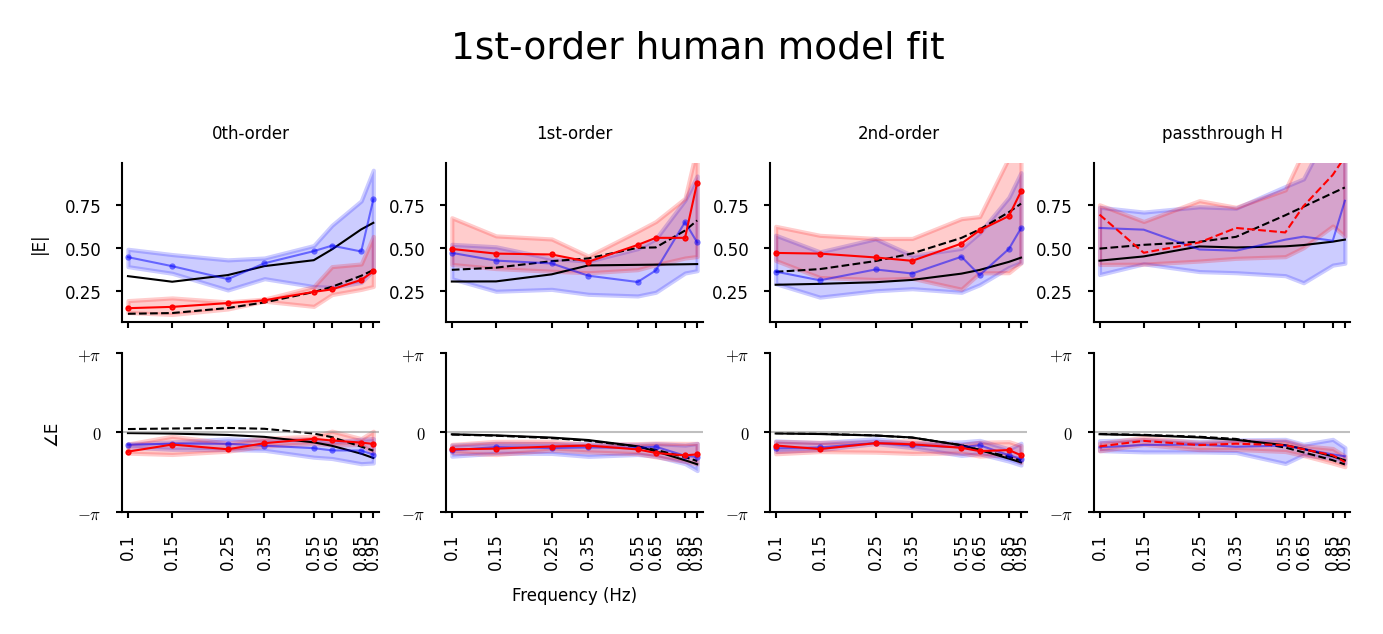

In [7]:
# plot the fitted 1st-order models, overlaying with the empirical data
xticks = np.array([0.1, 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.095, 1.0)
ylimphase = (-np.pi, np.pi)
yticksphase = [-np.pi, 0., np.pi]
yticklabelsphase = [r'$-\pi$', r'$0$', r'$+\pi$']
trial_num = Hs.shape[2]

fig, axs = plt.subplots(2, 4, sharex=True, figsize=(4.5, 1.9), dpi=300)

for cond, condition in enumerate(condition_orders):
    # fitted 1st-order model
    H_fit_last_3_trials = np.mean(H_1st_fits[:, cond, 15:18, :], axis=1) # last 3 adaptive trials
    H_fit_first_3_trials = np.mean(H_1st_fits[:, cond, :3, :], axis=1) # first 3 fixed trials

    ax = axs[0, cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_fit_last_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', color='black', label='1st-order fit, last')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_fit_first_3_trials), axis=0)
    ax.plot(freqs, quantile50, '--', color='black', label='1st-order fit, first')

    ax = axs[1, cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_fit_last_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', color='black')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_fit_first_3_trials), axis=0)
    ax.plot(freqs, quantile50, '--', color='black')

    # empirical data
    H_last_3_trials = np.mean(Hs[:, cond, 15:18, :][:, :, IX], axis=1) # last 3 adaptive trials
    H_first_3_trials = np.mean(Hs[:, cond, :3, :][:, :, IX], axis=1) # first 3 fixed trials

    ax = axs[0, cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_last_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', marker='.', color='blue', alpha=0.5, label='empirical last')
    ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='blue')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_first_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', marker='.', color='red', label='empirical first')
    ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red')
    ax.set_title(str(condition) + '-order')

    ax = axs[1, cond]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_last_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', marker='.', color='blue', alpha=0.5)
    ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='blue')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_first_3_trials), axis=0)
    ax.plot(freqs, quantile50, '-', marker='.', color='red')
    ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red')

# fitted baseline model
ax = axs[0, -1]
H_fit_base_last_3_trials = np.mean(H_1st_fits_base[:, -3:, :], axis=1) # last 3 baseline trials
H_fit_base_first_3_trials = np.mean(H_1st_fits_base[:, :3, :], axis=1) # first 3 baseline trials
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_fit_base_last_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='black')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_fit_base_first_3_trials), axis=0)
ax.plot(freqs, quantile50, '--', color='black')

ax = axs[1, -1]
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_fit_base_last_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='black')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_fit_base_first_3_trials), axis=0)
ax.plot(freqs, quantile50, '--', color='black')

# empirical baseline
ax = axs[0, -1]
H_base_last_3_trials = np.mean(Hs_base[:, -3:, :][:, :, IX], axis=1) # last 3 baseline trials
H_base_first_3_trials = np.mean(Hs_base[:, :3, :][:, :, IX], axis=1) # first 3 baseline trials
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_base_last_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='blue', alpha=0.5)
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='blue')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.abs(H_base_first_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='red', label='empirical first', linestyle='--')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red')
ax.set_title('passthrough H')

ax = axs[1, -1]
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_base_last_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='blue', alpha=0.5)
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='blue')
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(np.angle(H_base_first_3_trials), axis=0)
ax.plot(freqs, quantile50, '-', color='red', linestyle='--')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red')

for j in range(4):
    ax = axs[0, j]
    ax.set_xscale('log')
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=90)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axs[1, j]
    ax.set_ylim(ylimphase)
    ax.set_yticks(yticksphase)
    ax.set_yticklabels(yticklabelsphase)
    ax.set_xticklabels(xticks, rotation=90)
    ax.axhline(y=0, color='grey', alpha=0.5, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for j in range(1, 4):
    axs[0, j].sharey(axs[0, 0])

axs[0, 0].set_ylabel('|E|')
axs[1, 0].set_ylabel('∠E')
axs[1, 1].set_xlabel('Frequency (Hz)')
plt.suptitle('1st-order human model fit', y=1.04, fontsize=9)
plt.tight_layout()
plt.show()

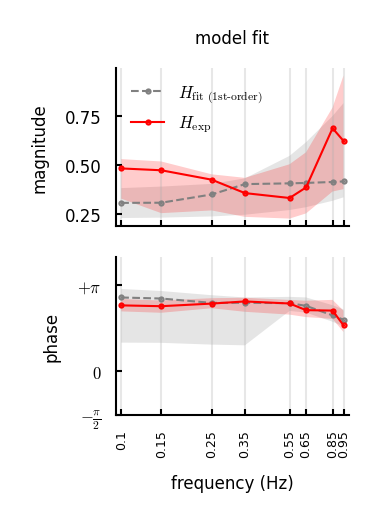

In [8]:


xlim = (0.095, 1.0)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
ylimphase = (-np.pi/2,np.pi+1)
yticksphase = [-np.pi/2,0.,np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$',r'$+\pi$']

fig,axs = plt.subplots(2,1,sharex=True,figsize=(1,1.5),dpi = 300)
cond = 1
ax = axs[0]
H_last_3_trials = np.mean(np.abs(-H_1st_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials  # invert H to match paper figure
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit (1st-order)}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# overlay exp result
H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1,label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([]) 
ax.set_ylabel('magnitude')
ax.set_title('model fit')
ax.tick_params(axis='y')

ax = axs[1]
H_last_3_trials = np.mean(np.angle(-H_1st_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# # overlay exp result
H_last_3_trials = np.mean(np.angle(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1, label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90, fontsize=TINY_SIZE-1) 
ax.set_ylabel('phase') 
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left',frameon = False,ncol = 1)
plt.show()

In [9]:
from scipy.stats import norm,wilcoxon,pearsonr 


# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

print('\n')

# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_1st_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

Correlation: 0.9776303080801207, P-value: 2.1228332343797546e-07
Correlation: 0.9517854993047241, P-value: 6.4782771190450935e-06
Correlation: 0.9032266656802724, P-value: 0.0001386838281942654
Correlation: 0.88008035078208, P-value: 0.0003516688558712945
Correlation: 0.9909818434518218, P-value: 3.6293365209848913e-09
Correlation: 0.9559023068795793, P-value: 4.3615037208199275e-06
Correlation: 0.9796335038270967, P-value: 1.3958057447453578e-07
Correlation: 0.9971053763310962, P-value: 2.2018010188869258e-11


Correlation: 0.7725609116925767, P-value: 0.005315583290689009
Correlation: 0.8155452537544137, P-value: 0.002213588895747079
Correlation: 0.8064162787508936, P-value: 0.0027126788391013505
Correlation: 0.8655124387696304, P-value: 0.0005763528912021303
Correlation: 0.9584572116502947, P-value: 3.346645812029802e-06
Correlation: 0.9884191608448227, P-value: 1.114365585990033e-08
Correlation: 0.9480640697887842, P-value: 9.003418445836819e-06
Correlation: 0.9379192058853545, P-v

In [ ]:
# Define the data to save
save_data = [H_2nd_params, H_2nd_fits, H_2nd_params_base, H_2nd_fits_base, H_1st_params, H_1st_fits, H_1st_params_base, H_1st_fits_base]

# # Define the file name
# file_name = 'human_model_fit_data.pkl'

# # Save the data in pickle
# pickle.dump(save_data, open(file_name, 'wb'))


In [ ]:
# # load pickle file
# with open('human_model_fit_data.pkl', 'rb') as f:
#     H_2nd_params, H_2nd_fits, H_2nd_params_base, H_2nd_fits_base, H_1st_params, H_1st_fits, H_1st_params_base, H_1st_fits_base = pickle.load(f)
